# Разведочный анализ данных

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv("data/interim/train.csv", index_col=0)

In [6]:
df

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,description,state,lat,long,posting_date
0,columbus,3995,2007.0,jeep,commander,NaN,6 cylinders,gas,149555.0,clean,automatic,4wd,NaN,grey,Will not last long at this price! Well maintai...,oh,40.059341,-83.019663,2021-05-04T17:42:23-0400
1,las vegas,28395,2018.0,honda,accord,NaN,4 cylinders,gas,30186.0,clean,automatic,fwd,sedan,brown,Most common questions about this vehicle: Wan...,nv,36.140961,-115.281091,2021-05-01T08:07:53-0700
2,albany,37888,2018.0,ram,1500 big horn,like new,8 cylinders,gas,46525.0,clean,automatic,4wd,truck,NaN,"2018 ***RAM 1500 BIG HORN 4X4 CREW CAB 5'7"" BO...",ny,43.317381,-73.625822,2021-04-20T09:58:43-0400
3,eugene,42500,2004.0,ford,f650,NaN,NaN,diesel,262884.0,clean,manual,NaN,NaN,NaN,2004 Ford F650 Extended Cab Diesel Service / U...,or,44.046393,-123.006379,2021-04-21T13:59:31-0700
4,maine,18995,2012.0,toyota,highlander,NaN,NaN,gas,74096.0,clean,automatic,NaN,other,black,2012 TOYOTA HIGHLANDER LIMITED Offered by:...,me,43.524562,-70.427884,2021-04-29T09:33:11-0400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189591,las vegas,3700,2000.0,jeep,grand cherokee laredo,good,6 cylinders,gas,190.0,clean,automatic,rwd,NaN,NaN,Very good condition Clean NV title in my poss...,nv,36.256000,-115.103000,2021-05-01T08:21:31-0700
189592,raleigh / durham / CH,2600,2003.0,honda,odyssey 2003,good,6 cylinders,gas,207850.0,clean,automatic,fwd,mini-van,brown,"For sale odyssey good conditions, power window...",nc,35.978100,-78.843900,2021-04-19T14:12:55-0400
189593,orange county,12999,2010.0,ford,f-150 platinum,excellent,8 cylinders,gas,190697.0,clean,automatic,rwd,truck,grey,"2010 FORD F-150 PLATINUM!! LUXURIOUS, FULLY LO...",ca,33.749000,-117.891262,2021-05-03T11:31:51-0700
189594,toledo,52500,2016.0,ford,NaN,excellent,NaN,diesel,51000.0,clean,automatic,NaN,NaN,green,One owner F350 Lariat 4x4 Fully loaded. Ha...,oh,41.594500,-83.871800,2021-04-09T11:47:36-0400


In [7]:
df.shape

(189596, 19)

In [8]:
nan_df = (df.isnull().mean() * 100).reset_index()
nan_df.columns = ["feature", "percentage"]
nan_df.sort_values('percentage', ascending=False, inplace=True)
nan_df

,feature,percentage
6,cylinders,37.785607
5,condition,35.452225
11,drive,29.182050
13,paint_color,27.741092
12,type,22.986772
3,manufacturer,4.287010
9,title_status,1.405093
4,model,1.343383
17,long,0.646111
16,lat,0.646111


In [9]:
df["price"].describe().apply(lambda x: f"{x:.2f}")

count    189596.00
mean      17838.99
std       14184.19
min         500.00
25%        6980.00
50%       13995.00
75%       25766.75
max      100000.00
Name: price, dtype: str

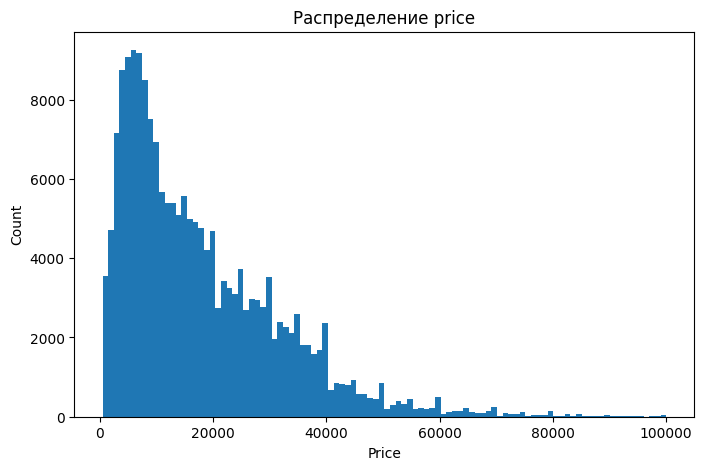

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=100)
plt.title("Распределение price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

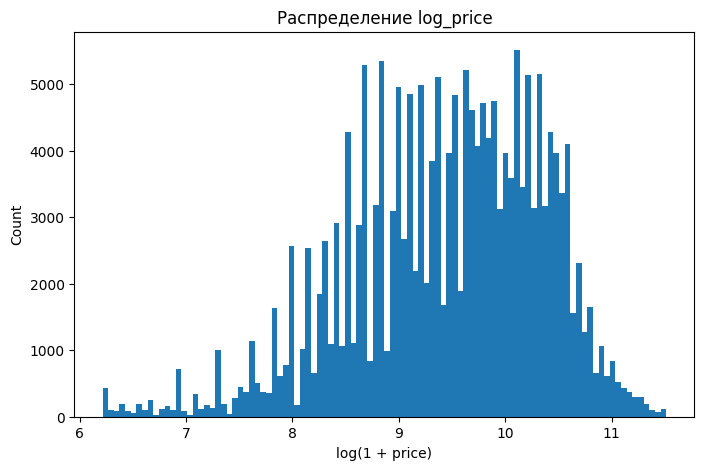

In [11]:
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=100)
plt.title("Распределение log_price")
plt.xlabel("log(1 + price)")
plt.ylabel("Count")
plt.show()

In [12]:
df["year"].describe()

count    189050.000000
mean       2009.991902
std          10.555715
min        1900.000000
25%        2007.000000
50%        2013.000000
75%        2016.000000
max        2022.000000
Name: year, dtype: float64

In [13]:
df[df["year"] < 1960][["price", "year", "manufacturer", "model", "odometer"]].head(20)

,price,year,manufacturer,model,odometer
10,18500,1923.0,ford,t bucket,123456.0
25,38000,1955.0,ford,f1000,5000.0
37,4500,1955.0,NaN,Bellaire,123459.0
223,35000,1958.0,cadillac,coupe de ville 62,51320.0
330,19000,1932.0,chevrolet,NaN,500.0
383,7500,1953.0,chevrolet,NaN,100000.0
396,27000,1958.0,bmw,isetta,8159.0
482,15000,1957.0,volkswagen,beetle,9999999.0
701,52000,1951.0,ford,custom deluxe,37200.0
948,39995,1955.0,chevrolet,other,384.0


In [14]:
df[df["year"] < 1960].shape

(1499, 20)

In [15]:
df = df[((df["year"] >= 1980))]

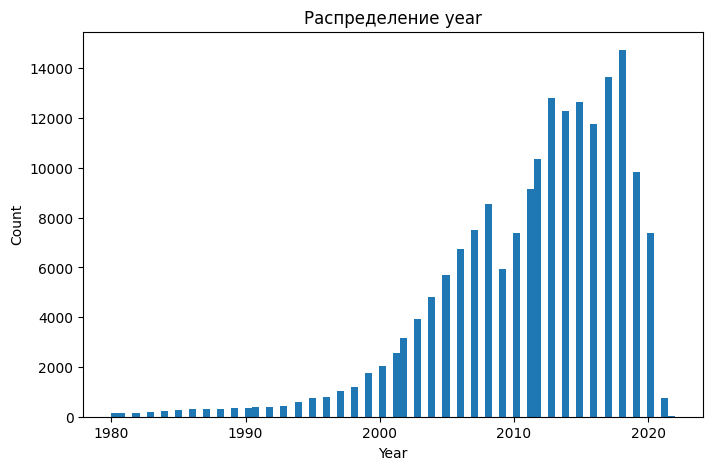

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["year"].dropna(), bins=80)
plt.title("Распределение year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

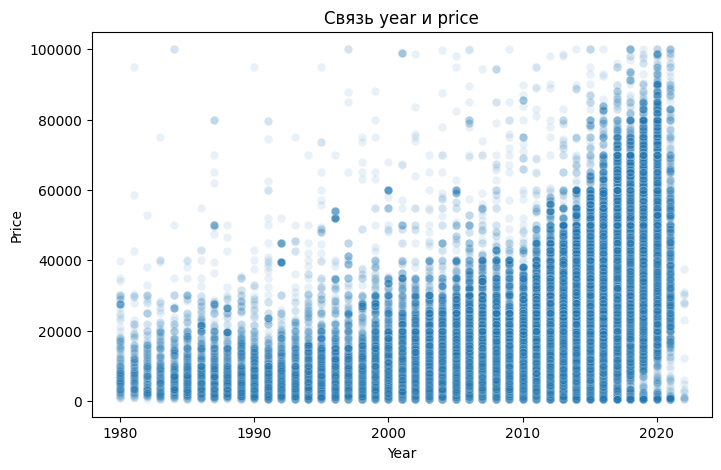

In [17]:
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="year",
    y="price",
    alpha=0.1
)

plt.title("Связь year и price")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

In [18]:
df["year"] = df["year"].fillna(df["year"].mode()[0])

In [19]:
df["odometer"].describe().apply(lambda x: f"{x:.2f}")

count      183070.00
mean       103406.07
std        168036.46
min             0.00
25%         43156.25
50%         94477.50
75%        142097.25
max      10000000.00
Name: odometer, dtype: str

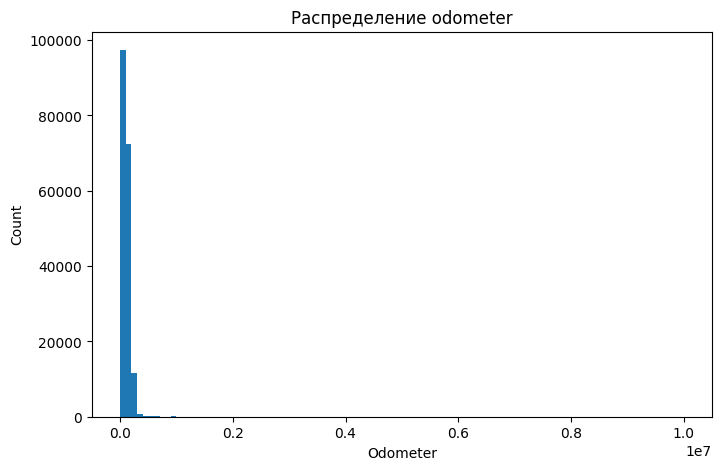

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["odometer"].dropna(), bins=100)
plt.title("Распределение odometer")
plt.xlabel("Odometer")
plt.ylabel("Count")
plt.show()

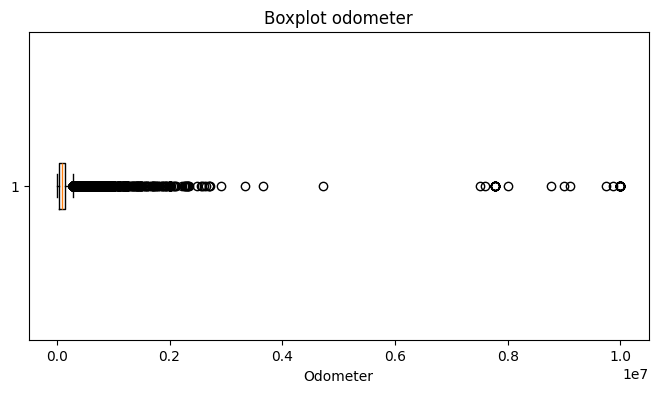

In [21]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["odometer"].dropna(), vert=False)
plt.title("Boxplot odometer")
plt.xlabel("Odometer")
plt.show()

In [22]:
print("odometer = 0:", (df["odometer"] == 0).sum())
print("odometer > 500000:", (df["odometer"] > 500000).sum())

df[df["odometer"] > 500000][["price", "year", "manufacturer", "model", "odometer"]].head(20)

odometer = 0: 377
odometer > 500000: 541


,price,year,manufacturer,model,odometer
114,1200,1996.0,ford,mustang,1760000.0
248,4500,2001.0,ford,expedition,1515962.0
1312,2500,1992.0,NaN,1992 g10 van,9999999.0
1508,13000,2002.0,porsche,boxster type s,1018000.0
1696,12500,1991.0,ram,2500,1000000.0
2431,9995,2015.0,fiat,500l trekking,636200.0
2479,14000,2008.0,NaN,mack pinnacle cxu613,570700.0
3028,22000,2012.0,NaN,Frtlner Cascadia,837000.0
3544,4500,2021.0,NaN,call today,1234567.0
3789,20000,2014.0,NaN,freightliner cascadia,869000.0


In [23]:
df = df[
    ((df["odometer"] > 0) & (df["odometer"] <= 500000))
].copy()

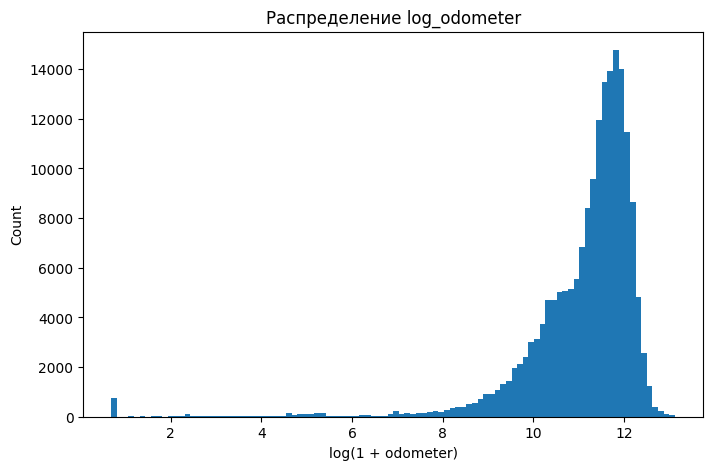

In [24]:
df["log_odometer"] = np.log1p(df["odometer"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_odometer"].dropna(), bins=100)
plt.title("Распределение log_odometer")
plt.xlabel("log(1 + odometer)")
plt.ylabel("Count")
plt.show()

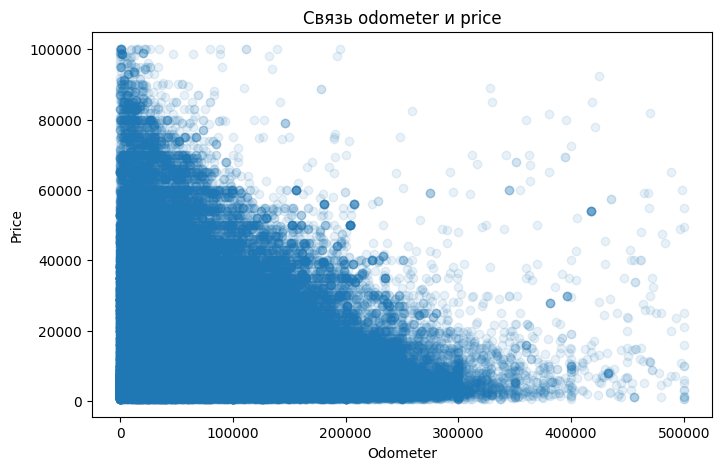

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df["odometer"], df["price"], alpha=0.1)
plt.title("Связь odometer и price")
plt.xlabel("Odometer")
plt.ylabel("Price")
plt.show()

In [26]:
df["odometer"] = df["odometer"].fillna(df["odometer"].mean())

In [27]:
df["posting_date"] = pd.to_datetime(
    df["posting_date"],
    errors="coerce",
    utc=True
)

df["posting_year"] = df["posting_date"].dt.year
df["posting_month"] = df["posting_date"].dt.month

df = df.drop(columns=["posting_date"])

In [28]:
df["posting_year"].nunique()

1

In [29]:
df.drop(columns=["posting_year"], inplace=True)

In [30]:
df["posting_month"].nunique()

2

In [31]:
df.drop(columns=["posting_month"], inplace=True)

In [32]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

categorical_cols

C:\Users\Alex\AppData\Local\Temp\ipykernel_9008\2376633327.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


['region',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'type',
 'paint_color',
 'description',
 'state']

In [33]:
cardinality_table = pd.DataFrame({
    "column": categorical_cols,
    "unique_count": [df[col].nunique(dropna=True) for col in categorical_cols],
    "missing_percent": [df[col].isna().mean() * 100 for col in categorical_cols]
})

cardinality_table = cardinality_table.sort_values("unique_count", ascending=False)

display(cardinality_table)

,column,unique_count,missing_percent
11,description,174215,0.000000
2,model,20174,1.106768
0,region,404,0.000000
12,state,51,0.000000
1,manufacturer,42,3.378497
9,type,13,22.394484
10,paint_color,12,27.415016
4,cylinders,8,37.954016
3,condition,6,35.432496
6,title_status,6,1.326365


In [34]:
df["model"].value_counts().head(20)

model
f-150             3158
silverado 1500    2075
1500              1690
accord            1448
camry             1426
silverado         1413
civic             1355
altima            1242
escape            1187
wrangler          1157
tacoma            1119
grand cherokee    1063
explorer          1050
2500              1026
corolla            931
mustang            921
cr-v               890
equinox            821
focus              816
fusion             790
Name: count, dtype: int64

In [35]:
model_counts = df["model"].value_counts(dropna=False)

n_unique = df["model"].nunique(dropna=False)

result = {
    "всего уникальных": n_unique,
    "встречаются 1 раз": (model_counts == 1).sum(),
    "встречаются меньше 5 раз": (model_counts < 5).sum(),
    "встречаются меньше 10 раз": (model_counts < 10).sum(),
    "встречаются меньше 20 раз": (model_counts < 20).sum(),
    "встречаются меньше 50 раз": (model_counts < 50).sum(),
}

result

{'всего уникальных': 20175,
 'встречаются 1 раз': np.int64(11699),
 'встречаются меньше 5 раз': np.int64(16027),
 'встречаются меньше 10 раз': np.int64(17702),
 'встречаются меньше 20 раз': np.int64(18809),
 'встречаются меньше 50 раз': np.int64(19622)}

In [36]:
model_counts = df["model"].value_counts(dropna=True)
popular_models = model_counts[model_counts >= 20].index

df["model"] = df["model"].fillna("unknown")

df["model"] = df["model"].where(
    df["model"].isin(popular_models) | (df["model"] == "unknown"),
    "other"
)

In [37]:
df["model"].nunique(dropna=False)

1367

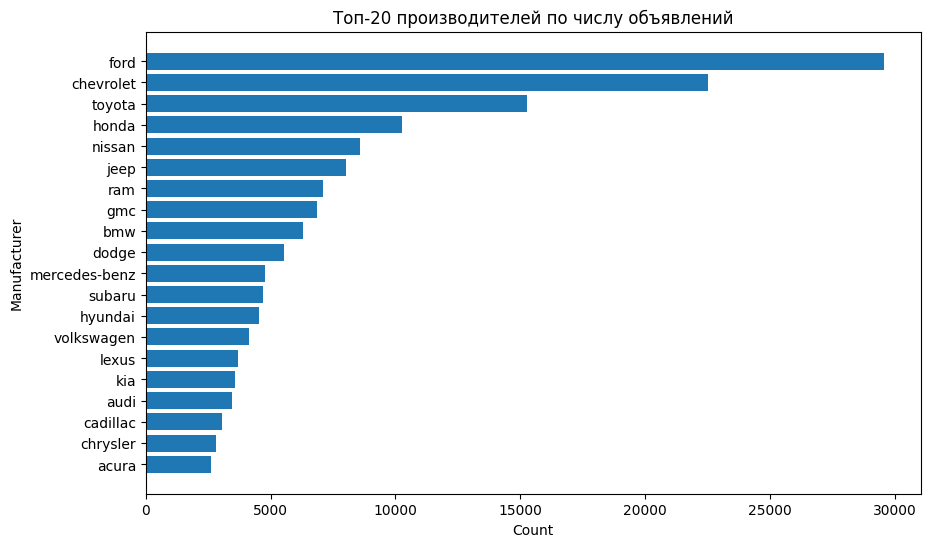

In [38]:
top_manufacturers = df["manufacturer"].value_counts().head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_manufacturers.index, top_manufacturers.values)
plt.title("Топ-20 производителей по числу объявлений")
plt.xlabel("Count")
plt.ylabel("Manufacturer")
plt.gca().invert_yaxis()
plt.show()

<Figure size 1200x600 with 0 Axes>

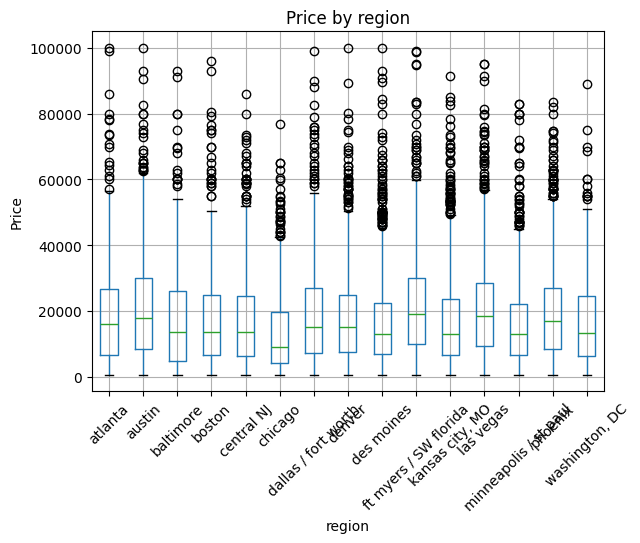

<Figure size 1200x600 with 0 Axes>

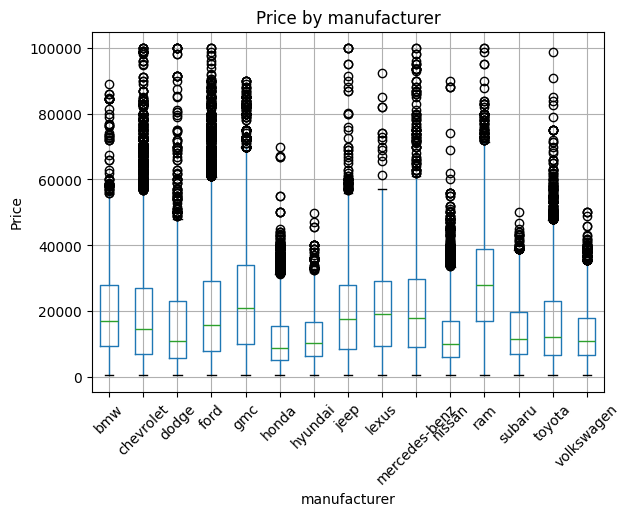

<Figure size 1200x600 with 0 Axes>

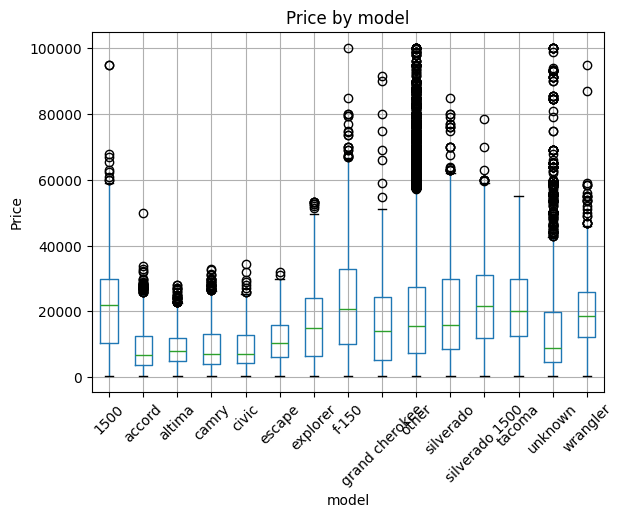

<Figure size 1200x600 with 0 Axes>

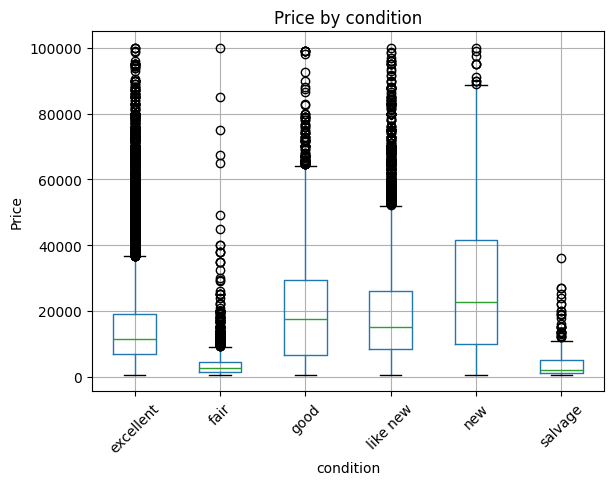

<Figure size 1200x600 with 0 Axes>

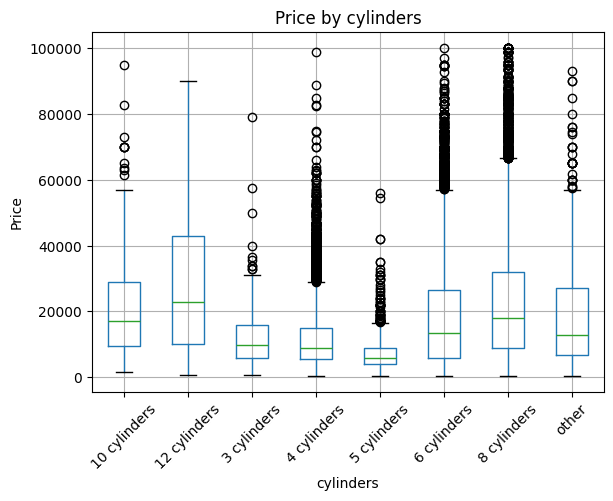

<Figure size 1200x600 with 0 Axes>

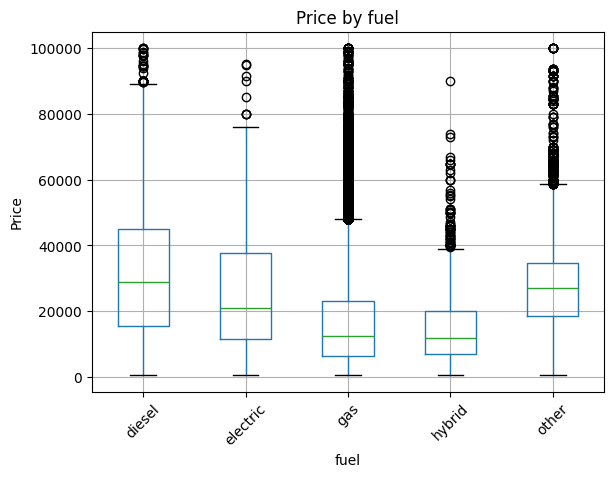

<Figure size 1200x600 with 0 Axes>

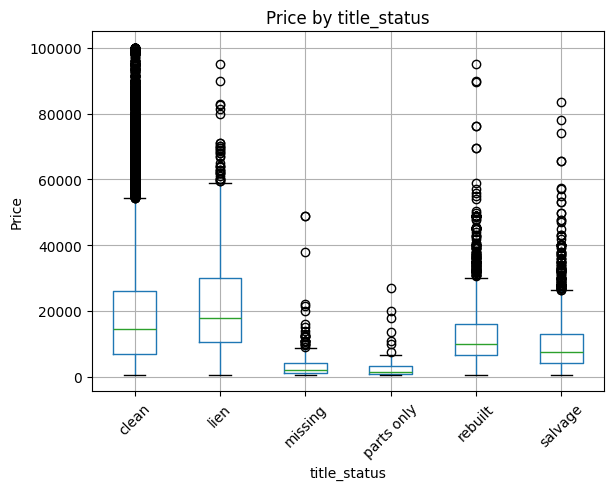

<Figure size 1200x600 with 0 Axes>

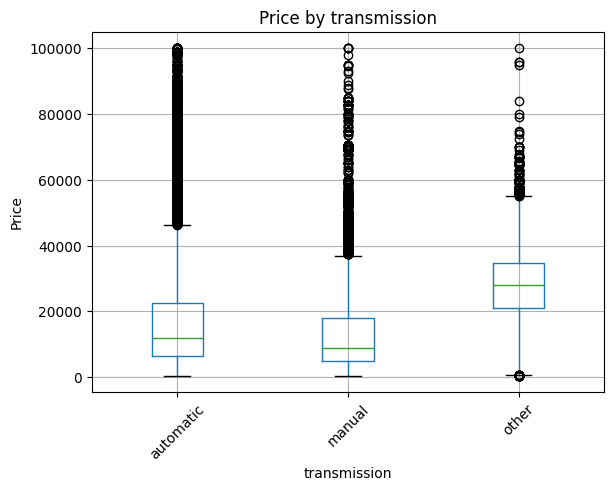

<Figure size 1200x600 with 0 Axes>

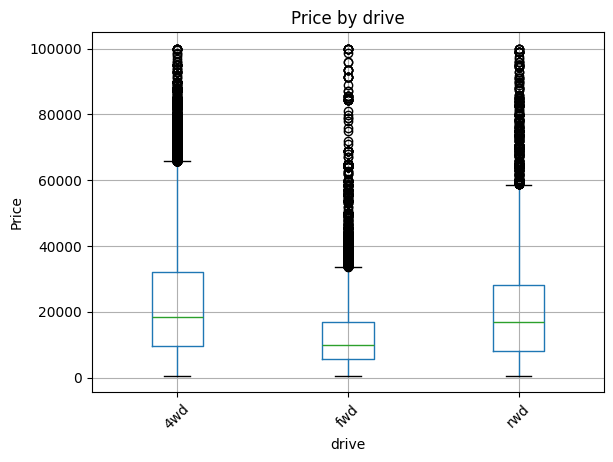

<Figure size 1200x600 with 0 Axes>

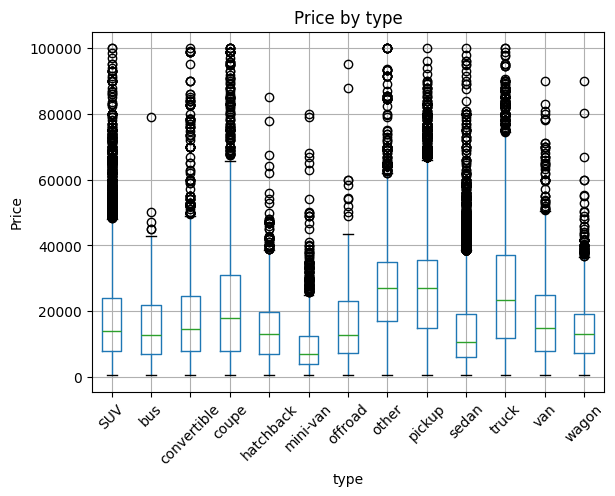

<Figure size 1200x600 with 0 Axes>

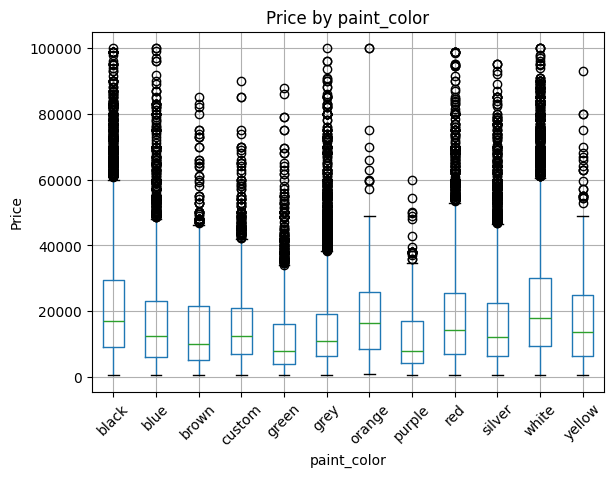

In [39]:
import matplotlib.pyplot as plt

categorical_features = [
    "region",
    "manufacturer",
    "model",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color"
]

top_n = 15

for col in categorical_features:
    if col not in df.columns:
        print(f"Колонка {col} отсутствует в датасете")
        continue
    
    top_categories = df[col].value_counts().head(top_n).index
    
    plot_data = df[df[col].isin(top_categories)]
    
    plt.figure(figsize=(12, 6))
    plot_data.boxplot(column="price", by=col, rot=45)
    
    plt.title(f"Price by {col}")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

In [40]:
region_state_check = (
    df.groupby("region")["state"]
    .nunique()
    .sort_values(ascending=False)
)

display(region_state_check.head(20))

region
jackson                    3
eastern shore              2
cumberland valley          2
jacksonville               2
duluth / superior          2
lewiston / clarkston       2
columbus                   2
charleston                 2
fayetteville               2
monroe                     2
omaha / council bluffs     2
pullman / moscow           2
reno / tahoe               2
richmond                   2
rochester                  2
albany                     2
spokane / coeur d'alene    2
springfield                2
athens                     2
waco                       1
Name: state, dtype: int64

In [41]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

geo_df = df.dropna(subset=["lat", "long", "state"]).copy()

X_geo = geo_df[["lat", "long"]]
y_state = geo_df["state"]

clf = DecisionTreeClassifier(
    max_depth=10,
)

scores = cross_val_score(
    clf,
    X_geo,
    y_state,
    cv=5,
    scoring="accuracy"
)

print("Accuracy predicting state from lat/long:", scores.mean())

Accuracy predicting state from lat/long: 0.8591409048864982


In [42]:
df["lat_long_missing"] = (
    df["lat"].isna() | df["long"].isna()
).astype(int)

for col in ["lat", "long"]:
    df[col] = df[col].fillna(
        df.groupby("state")[col].transform("median")
    )

    df[col] = df[col].fillna(df[col].median())

Штат сильно коррелирует с координатами, поэтому чтобы снизить количество one hot колонок стоит попробовать удалить этот признак

In [43]:
df.drop(columns=["state"], inplace=True)

In [44]:
geo_df = df.dropna(subset=["lat", "long", "region"]).copy()

X_geo = geo_df[["lat", "long"]]
y_state = geo_df["region"]

clf = DecisionTreeClassifier(
    max_depth=10,
)

scores = cross_val_score(
    clf,
    X_geo,
    y_state,
    cv=5,
    scoring="accuracy"
)

print("Accuracy predicting region from lat/long:", scores.mean())

d:\VS code\Projects\PythonProjects\spbu_AI_technology_practice\project\project_venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Accuracy predicting region from lat/long: 0.2859479941599239


Признак region не дает сильной корреляции с координатами

In [45]:
from sklearn.cluster import KMeans

region_price = (
    df
    .assign(region=df["region"].fillna("unknown"))
    .groupby("region")["price"]
    .median()
    .reset_index()
)

kmeans = KMeans(
    n_clusters=10,
    n_init=10
)

region_price["region_cluster"] = kmeans.fit_predict(
    region_price[["price"]]
)

cluster_order = (
    region_price
    .groupby("region_cluster")["price"]
    .median()
    .sort_values()
    .index
)

cluster_map = {
    old_cluster: new_cluster
    for new_cluster, old_cluster in enumerate(cluster_order)
}

region_price["region_cluster"] = (
    region_price["region_cluster"]
    .map(cluster_map)
)

region_to_cluster = dict(
    zip(region_price["region"], region_price["region_cluster"])
)

df["region"] = df["region"].fillna("unknown")

df["region_price_cluster"] = (
    df["region"]
    .map(region_to_cluster)
    .astype("category")
)

df = df.drop(columns=["region"])

In [46]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

paint_color_price = (
    df
    .assign(paint_color=df["paint_color"].fillna("unknown"))
    .groupby("paint_color")["price"]
    .median()
    .reset_index()
)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

paint_color_price["paint_color_cluster"] = kmeans.fit_predict(
    paint_color_price[["price"]]
)

cluster_order = (
    paint_color_price
    .groupby("paint_color_cluster")["price"]
    .median()
    .sort_values()
    .index
)

cluster_map = {
    old_cluster: new_cluster
    for new_cluster, old_cluster in enumerate(cluster_order)
}

paint_color_price["paint_color_cluster"] = (
    paint_color_price["paint_color_cluster"]
    .map(cluster_map)
)

paint_color_to_cluster = dict(
    zip(paint_color_price["paint_color"], paint_color_price["paint_color_cluster"])
)

df["paint_color"] = df["paint_color"].fillna("unknown")

df["paint_color_price_cluster"] = (
    df["paint_color"]
    .map(paint_color_to_cluster)
    .astype("category")
)

df = df.drop(columns=["paint_color"])

In [47]:
cols_to_fill = [
    "type",
    "drive",
    "transmission",
    "fuel",
    "condition",
    "manufacturer",
    "title_status"
]

for col in cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")

In [48]:
df["cylinders"].unique()

<StringArray>
[ '6 cylinders',  '4 cylinders',  '8 cylinders',            nan,
  '5 cylinders',        'other', '10 cylinders',  '3 cylinders',
 '12 cylinders']
Length: 9, dtype: str

In [49]:
import numpy as np

cylinders_map = {
    "3 cylinders": 3,
    "4 cylinders": 4,
    "5 cylinders": 5,
    "6 cylinders": 6,
    "8 cylinders": 8,
    "10 cylinders": 10,
    "12 cylinders": 12,
    "other": 0
}

df["cylinders_other"] = (df["cylinders"] == "other").astype(int)

df["cylinders"] = (
    df["cylinders"]
    .map(cylinders_map)
    .fillna(0)
    .astype(int)
)

In [50]:
df["description"] = df["description"].fillna("")

In [51]:
df.drop(columns=["price"], inplace=True)

In [52]:
nan_df = (df.isnull().mean() * 100).reset_index()
nan_df.columns = ["feature", "percentage"]
nan_df.sort_values('percentage', ascending=False, inplace=True)
nan_df

,feature,percentage
0,year,0.0
1,manufacturer,0.0
2,model,0.0
3,condition,0.0
4,cylinders,0.0
5,fuel,0.0
6,odometer,0.0
7,title_status,0.0
8,transmission,0.0
9,drive,0.0


In [53]:
df

,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,description,lat,long,log_price,log_odometer,lat_long_missing,region_price_cluster,paint_color_price_cluster,cylinders_other
0,2007.0,jeep,commander,unknown,6,gas,149555.0,clean,automatic,4wd,unknown,Will not last long at this price! Well maintai...,40.059341,-83.019663,8.293049,11.915426,0,3,1,0
1,2018.0,honda,accord,unknown,4,gas,30186.0,clean,automatic,fwd,sedan,Most common questions about this vehicle: Wan...,36.140961,-115.281091,10.254004,10.315167,0,6,1,0
2,2018.0,ram,1500 big horn,like new,8,gas,46525.0,clean,automatic,4wd,truck,"2018 ***RAM 1500 BIG HORN 4X4 CREW CAB 5'7"" BO...",43.317381,-73.625822,10.542416,10.747767,0,6,2,0
3,2004.0,ford,f650,unknown,0,diesel,262884.0,clean,manual,unknown,unknown,2004 Ford F650 Extended Cab Diesel Service / U...,44.046393,-123.006379,10.657283,12.479472,0,2,2,0
4,2012.0,toyota,highlander,unknown,0,gas,74096.0,clean,automatic,unknown,other,2012 TOYOTA HIGHLANDER LIMITED Offered by:...,43.524562,-70.427884,9.851984,11.213130,0,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189591,2000.0,jeep,grand cherokee laredo,good,6,gas,190.0,clean,automatic,rwd,unknown,Very good condition Clean NV title in my poss...,36.256000,-115.103000,8.216358,5.252273,0,6,2,0
189592,2003.0,honda,other,good,6,gas,207850.0,clean,automatic,fwd,mini-van,"For sale odyssey good conditions, power window...",35.978100,-78.843900,7.863651,12.244577,0,2,1,0
189593,2010.0,ford,f-150 platinum,excellent,8,gas,190697.0,clean,automatic,rwd,truck,"2010 FORD F-150 PLATINUM!! LUXURIOUS, FULLY LO...",33.749000,-117.891262,9.472705,12.158446,0,2,1,0
189594,2016.0,ford,unknown,excellent,0,diesel,51000.0,clean,automatic,unknown,unknown,One owner F350 Lariat 4x4 Fully loaded. Ha...,41.594500,-83.871800,10.868587,10.839601,0,2,0,0


In [54]:
df.columns

Index(['year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'odometer', 'title_status', 'transmission', 'drive', 'type',
       'description', 'lat', 'long', 'log_price', 'log_odometer',
       'lat_long_missing', 'region_price_cluster', 'paint_color_price_cluster',
       'cylinders_other'],
      dtype='str')

In [56]:
df = pd.read_csv("data/interim/train.csv", index_col=0)

In [57]:
df = df[((df["year"] >= 1980))]
df = df[
    ((df["odometer"] > 0) & (df["odometer"] <= 500000))
].copy()

In [59]:
df.to_csv("data/interim/train_filtered.csv")